# EDA: Detección de Fraude en Pagos Digitales

<big>**Integrantes**<big>

Estefania Cervera CC:1018475210\
Andres Felipe Orozco Roa CC: 1146436096\
Cristina Garces ÁLvarez CC: 1000914447

## Contexto y Motivación del Análisis:

El crecimiento acelerado de los pagos digitales ha transformado la forma en que las personas realizamos transacciones financieras en nuestra cotidianidad. Hoy en día, operaciones como transferencias, un simple pago de servicios o compras en línea se realizan de manera inmediata a través de plataformas digitales y dispositivos móviles. Sin embargo, está inmediatez tecnológica también genera  que las plataformas deban ser mas robustas a nivel de seguridad, ya que el gran volumen de transacciones generan brechas para que personas malintencionada intenten cometer fraudes aprovechando vulnerabilidades en los sistemas o en el comportamiento de los usuarios.

En este contexto, el análisis de datos de este tipo de dataset se convierte en una herramienta fundamental para comprender cómo se comportan las transacciones dentro de estas plataformas digitales, validar si con base a variables como la cantidad de dinero de la transacción, el tipo de dispositivo utilizado, la ubicación del cliente, el tipo de usuario, los intentos fallidos de acceso y otros factores, nos ayudan a identificar patrones que permitan diferenciar operaciones reales de aquellas potencialmente fraudulentas.

## Objetivo:

Analizar y comprender el conjunto de datos de transacciones digitales para identificar patrones de comportamiento, anomalías y relaciones multivariadas que diferencien las transacciones genuinas de las fraudulentas. Este análisis servirá para limpiar los datos, generar nuevas características relevantes (Feature Engineering) y sentar las bases estratégicas para el entrenamiento de modelos predictivos de Machine Learning eficaces.

## ¿Por qué este proyecto?

En el ecosistema financiero actual, el fraude no es solo una pérdida de dinero; es una perdida de confianza. Elegimos este conjunto de datos de Kaggle porque representa el desafío del pajar: las transacciones fraudulentas son raras (menos del 7%), pero su impacto es devastador.

No solo queremos encontrar el fraude, queremos entender el comportamiento del defraudador para anticiparnos.

## Diccionario de Datos Dataset

El conjunto de datos utilizado para este análisis contiene información detallada sobre transacciones digitales realizadas por distintos usuarios dentro de una plataforma de pagos. Cada registro representa una transacción e incluye variables que brinda información de  las características de la operación, como la columna "Transaction_amount" (monto de la transacción) y la columna "Transaction_type" (tipo de movimiento realizado), así como el método de pago utilizado (Payment_mode). Además, se visualizan identificadores como las columnas "Transaction_id" y "User_id", que permiten localizar cada operación y asociarla con el usuario.

Adicionalmente, el dataset incluye variables que describen el entorno tecnológico y el comportamiento del usuario, tales como las columnas "Device_type" y "Device_location", que permiten indicar desde qué dispositivo y ubicación se realizó la transacción. También se pueden identificar aspectos relevantes para el análisis de riesgo, como el tiempo de creación de la cuenta en la columna "Account_age_days", los intentos erróneos en la columna "Previous_failed_attempts", los intentos de logueo en las últimas 24 horas en la columna "Login_attempts_last_24h", el puntaje de riesgo de la IP en la columna "Ip_risk_score" e inclusive si el origen de la transacción es internacional en la columna "Is_international". Finalmente, la columna "Fraud_label" que actúa como variable objetivo, clasificando cada transacción como fraudulenta (1) o real (0), lo cual permitirá identificar patrones de comportamiento.

A continuacion detallaremos las columnas que la Data posee para realizar nuestro analisis exploratorio.

**- Transaction_id:** Identificador único de cada transacción (Alfanumérico).

**- User_id:** Identificador único del usuario que realiza la operación.

**- Transaction_amount:** Monto de la transacción actual en la moneda local.

**- Transaction_type:** Tipo de movimiento realizado (Transferencia, Pago, Retiro).

**- Payment_mode:** Método de pago utilizado (Tarjeta, Billetera Digital, UPI, NetBanking).

**- Device_type:** Sistema operativo o plataforma desde donde se originó la transacción (Android, iOS, Web).

**- Device_location:** Ciudad o región desde donde se conectó el dispositivo.

**- Account_age_days:** Antigüedad de la cuenta del usuario en días.

**- Transaction_hour:** Hora del día en formato 24h (0 - 23) en la que ocurrió la transacción.

**- Previous_failed_attempts:** Cantidad de transacciones fallidas previas registradas para ese usuario.

**- Avg_transaction_amount:** Monto promedio histórico de transacciones realizadas por el usuario.

**- Is_international:** Variable binaria (1 = Sí, 0 = No) que indica si la transacción cruzó fronteras internacionales.

**- Ip_risk_score:** Puntaje de riesgo (0.0 a 1.0) asignado a la dirección IP desde donde se conectó el usuario.

**- Login_attempts_last_24h:** Número de intentos de inicio de sesión en la cuenta durante las últimas 24 horas.

**- Fraud_label:** Variable Objetivo. (1 = Transacción Fraudulenta, 0 = Transacción Genuina).

## Clasificación analítica de las variables

### 📂 Clasificación de Variables

* **Variables identificadoras:** `Transaction_id`, `User_id`
* **Variables transaccionales:** `Transaction_amount`, `Transaction_type`, `Payment_mode`
* **Variables de identificación tecnológica:** `Device_type`, `Device_location`
* **Variables de perfil usuario:** `Account_age_days`, `Avg_transaction_amount`
* **Variables de seguridad:** `Previous_failed_attempts`, `Login_attempts_last_24h`
* **Variables de riesgo:** `Ip_risk_score`, `Is_international`
* **Variable objetivo:** `Fraud_label` 

# 1. Configuracion de la Data

Como primer paso procederemos a la Importación de librerías (pandas, matplotlib, seaborn y numpy) , cargaremos el dataset y realizaremos una visualizacion parcial del mismo para confirmar que se realizao de manera correcta , para dar comienzo a nuestros analisis.

In [43]:
#Activemos el ambiente  en cmd .venv\Scripts\activate
#Importamos las librerías para usar en el EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [44]:
#Cargamos el dataset en csv que se encuentra en la carpeta
df= pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv",sep=",",header="infer")

print('Archivo Pagos Cargado Exitosamente')

#Previsualizamos la información para ver que columnas tiene y que información puede estar en cada columna
df.head(3)

Archivo Pagos Cargado Exitosamente


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0


# 2. Descripción del Dataset

A traves de  los metodos de descripcion de python y sus librerias validaremos la estructura que la data posee, haciendo revision de las dimensiones, tipos de datos y las medidas estadisticas basicas tanto para las variables numericas como las variables categoricas.

Inicialmente tomaremos como referencia una porcion de la data de manera aleatoria para tener conocimiento de los datos que esta nos esta entregando la dataset dentro del analisis exploratorio , por lo cual realizaremos mediante el metodo Sample  con el parametro random_state para no variar dicha porcion aleatoria para efectos del ejercicio.

In [45]:
df.sample(n=10, random_state=10)

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
4984,T4985,U7989,27555.49,Withdrawal,Card,Web,Bangalore,900,22,1,7270.27,0,0.917,1,0
1852,T1853,U8878,43075.43,Payment,UPI,Web,Chennai,515,17,0,15360.09,0,0.995,9,0
66,T67,U9847,7089.17,Transfer,Card,Android,Hyderabad,1800,22,4,24550.03,0,0.585,9,0
216,T217,U6936,16303.71,Withdrawal,Card,Android,Delhi,745,1,4,12963.44,0,0.187,8,0
5911,T5912,U6902,46332.94,Withdrawal,UPI,Web,Bangalore,405,6,0,18304.86,0,0.017,4,0
5526,T5527,U5090,31966.20,Transfer,UPI,iOS,Delhi,875,8,0,6241.30,0,0.798,3,0
191,T192,U6183,44865.93,Transfer,Wallet,Android,Delhi,1038,1,4,4224.42,0,0.556,8,0
5610,T5611,U3713,3894.61,Withdrawal,Wallet,iOS,Mumbai,1816,21,3,14820.23,0,0.238,1,0
7421,T7422,U3944,34519.26,Withdrawal,Card,Android,Chennai,1527,20,3,17741.98,0,0.591,8,1
7155,T7156,U4289,41146.87,Transfer,Wallet,iOS,Hyderabad,1872,7,0,16820.48,0,0.265,5,0


Luego de la validación del conjunto de datos de la data utilizaremos el Metodo Info para saber la descripcion de las data  en cuanto numero de columnas, numero filas o registros , valores nulos por columna y tipo de datos por columna.La selección de 10 registros aleatorios facilita la identificación preliminar de patrones, valores atípicos o posibles inconsistencias en diferentes variables del dataset, como montos de transacción, ubicaciones de los dispositivos o indicadores de riesgo

Además realizaremos un dataframe para visualizar los valores únicos por columna y una descripción del dataset.

In [46]:
print("\n🔍  Descripción del dataset")
print("-" * 40)
# 1. Número de filas y columnas
filas, columnas = df.shape

# 2. Información de cada columna
df.info()

# 3. Diccionario simple de datos
info_columnas = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})
display(info_columnas)


🔍  Descripción del dataset
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64

,Tipo de Dato,Valores Nulos,Valores Únicos
transaction_id,object,0,7500
user_id,object,0,5106
transaction_amount,float64,0,7499
transaction_type,object,0,3
payment_mode,object,0,4
device_type,object,0,3
device_location,object,0,5
account_age_days,int64,0,1943
transaction_hour,int64,0,24
previous_failed_attempts,int64,0,5


El conjunto de datos contiene 7.500 registros y 15 variables, donde cada fila representa una transacción digital realizada por un usuario. Las columnas incluyen información relacionada con el monto de la transacción, el tipo de operación, el método de pago, el dispositivo desde el cual se realiza la operación y diversos indicadores de comportamiento y riesgo asociados al usuario.

A partir de la exploración inicial se observa que el dataset combina variables categóricas (tipo de transacción, método de pago, dispositivo y ubicación) con variables numéricas (montos, antigüedad de la cuenta, intentos fallidos y puntaje de riesgo, entre otras). Además, todas las columnas presentan 7.500 valores no nulos, lo que indica que el dataset no contiene datos faltantes, facilitando el análisis exploratorio y el desarrollo posterior de modelos de detección de fraude utilizando la variable objetivo fraud_label.

Posteriormente, al validar la estructura del dataset, se identificó que este está compuesto por 9 columnas numéricas y 6 categóricas, para un total de 15 variables y 7.500 registros. Asimismo, se observó la presencia de 5.106 usuarios únicos, lo que sugiere que algunos usuarios realizan múltiples transacciones. Con base en esta revisión inicial, se procede a analizar las medidas estadísticas básicas de las variables numéricas mediante el método describe() de Python.

In [47]:
#Revisemos estadística basica para cada columna Numericas
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


A partir del análisis de las estadísticas descriptivas de las variables numéricas, se observa que el monto promedio de las transacciones es de aproximadamente 24.813, con valores que oscilan entre 50.58 y 49.985.90, lo que indica una amplia variabilidad en los montos transaccionados. Asimismo, el monto promedio histórico por usuario se sitúa alrededor de 15.129, lo cual permitirá posteriormente comparar si ciertas transacciones se desvían significativamente del comportamiento habitual del usuario, aspecto que suele ser relevante en la detección de fraude.

En cuanto al comportamiento de los usuarios, se observa que la antigüedad promedio de las cuentas es de aproximadamente 1.006 días, con cuentas que van desde 10 hasta 1.999 días de antigüedad. Adicionalmente, el número promedio de intentos fallidos previos es cercano a 2, mientras que los intentos de inicio de sesión en las últimas 24 horas presentan un promedio de 5 intentos, lo cual podría ser un indicador relevante al analizar posibles actividades sospechosas.

Por otro lado, se observa que aproximadamente el 10% de las transacciones son internacionales, mientras que el puntaje promedio de riesgo de la dirección IP es cercano al 0.50.

Conforme la aplicación de este análisis podemos empezar a ver que columnas podrián ser de nuestro interés para el análisis exploratorio en las posibles hipotésis a plantear, y continuaremos con el describe pero a las columnas de caracter string o Object.

In [48]:
#Revisemos Estadisticas Basicas para las columnas String o objetc
df.describe(include="object")

,transaction_id,user_id,transaction_type,payment_mode,device_type,device_location
count,7500,7500,7500,7500,7500,7500
unique,7500,5106,3,4,3,5
top,T7500,U1247,Payment,Card,Web,Hyderabad
freq,1,6,2511,1912,2537,1614


El análisis de las variables categóricas permite comprender la distribución de las principales características relacionadas con las transacciones y los usuarios. A partir de las estadísticas descriptivas se observa que el dataset contiene 7.500 identificadores únicos de transacción, lo que confirma que cada registro corresponde a una operación distinta dentro del sistema. Asimismo, se identifican 5.106 usuarios únicos, lo que indica que algunos usuarios han realizado múltiples transacciones dentro del conjunto de datos.

Al finalizar el análisis que describe la data podemos concluir que la variable objetivo dentro de nuestro analisis es fraud_label en el cual basar los analisis posteriores de caranter univariado , bivariado y multivariado que conforme a los indicios evidenciados en los anterirores analisis nos brinden patrones para lograr nuestro objetivo.

# 3.Análisis Univariado, Bivariado y Multivariado:

Conforme a la conclusion anterior y definido la variable objetivo Fraud_label vamos a realizar el discribe pero solo a los registrso que cumple criterio de fraude, por lo cual realizamos un dataframe y aplicamos  el metodo describe.

In [49]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.0
mean,24256.210879,1071.456033,11.568507,2.096115,15310.463313,0.083845,0.508689,5.155419,1.0
std,14289.574936,566.853237,6.873261,1.418902,8702.706731,0.277438,0.301381,2.557610,0.0
min,245.720000,10.000000,0.000000,0.000000,392.350000,0.000000,0.000000,1.000000,1.0
25%,11770.370000,564.000000,6.000000,1.000000,7576.580000,0.000000,0.245000,3.000000,1.0
50%,24260.580000,1108.000000,12.000000,2.000000,15421.840000,0.000000,0.485000,5.000000,1.0
75%,35936.770000,1566.000000,18.000000,3.000000,22738.260000,0.000000,0.790000,7.000000,1.0
max,49985.900000,1996.000000,23.000000,4.000000,29826.310000,1.000000,0.995000,9.000000,1.0


Antes de analizar variables, debemos entender a qué nos enfrentamos. El fraude es una anomalía, no la norma. Para esto queremos saber cual es la proporcion de transacciones calificadas como fraudulentas vs las transacciones genuinas

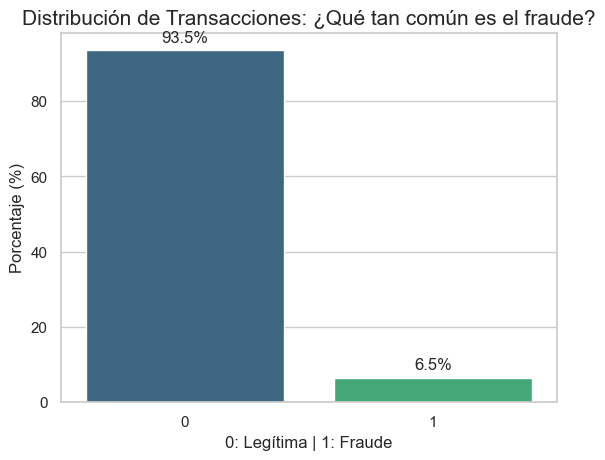

In [50]:
fraud_counts = df['fraud_label'].value_counts(normalize=True) * 100

ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')
plt.title('Distribución de Transacciones: ¿Qué tan común es el fraude?', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('0: Legítima | 1: Fraude')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

El 6.5% de las transacciones es considerada fraudulenta, queremos entender de estos registros si vemos en sus medidas estadísticas algo que nos pueda llamar la atención, para guiar el análisis por ese camino

Conforme a la conclusion anterior y definido la variable objetivo Fraud_label vamos a realizar el discribe pero solo a los registrso que cumple criterio de fraude, por lo cual realizamos un dataframe y aplicamos  el metodo describe.

In [51]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.0
mean,24256.210879,1071.456033,11.568507,2.096115,15310.463313,0.083845,0.508689,5.155419,1.0
std,14289.574936,566.853237,6.873261,1.418902,8702.706731,0.277438,0.301381,2.557610,0.0
min,245.720000,10.000000,0.000000,0.000000,392.350000,0.000000,0.000000,1.000000,1.0
25%,11770.370000,564.000000,6.000000,1.000000,7576.580000,0.000000,0.245000,3.000000,1.0
50%,24260.580000,1108.000000,12.000000,2.000000,15421.840000,0.000000,0.485000,5.000000,1.0
75%,35936.770000,1566.000000,18.000000,3.000000,22738.260000,0.000000,0.790000,7.000000,1.0
max,49985.900000,1996.000000,23.000000,4.000000,29826.310000,1.000000,0.995000,9.000000,1.0


In [52]:
df.columns

Index(['transaction_id', 'user_id', 'transaction_amount', 'transaction_type',
       'payment_mode', 'device_type', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts',
       'avg_transaction_amount', 'is_international', 'ip_risk_score',
       'login_attempts_last_24h', 'fraud_label'],
      dtype='object')

Despues de este Describe podemos ver que hay 489 Registros marcados como fraudulentos con respecto a los 7500 registros totales y se realiza una descripcion estadistica de las variables numericas del Dataset tenien como referencia columnas como los  montos las horas e intentos fallido  de las transaciones. 

Tambien lo aplicaremos el describe a las variables categoricas con el dataframe previamente creado.

In [53]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude para variables categoricas
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe(include="object")

,transaction_id,user_id,transaction_type,payment_mode,device_type,device_location
count,489,489,489,489,489,489
unique,489,482,3,4,3,5
top,T7458,U7573,Withdrawal,Card,Android,Hyderabad
freq,1,2,170,135,172,115


En cuanto a las características operativas de las transacciones, se identifican 3 tipos de transacción, 4 métodos de pago, 3 tipos de dispositivos y 5 ubicaciones de conexión. Entre las categorías más frecuentes se observa que el tipo de transacción predominante es Payment, el método de pago más utilizado es Card, el dispositivo más común para realizar operaciones es Web, y la ubicación con mayor número de transacciones registradas es Hyderabad.

Concluido el análisis vemos que las transaciones fraudulentas en correlación a toda la problación de la data no difieren mucho en cuanto los valores medios de montos 24813 y 24256 ,ni en cuanto a las hora promedio totales 11.435 a las de los fraudes 11.568 , lo que si vemos es que por tipo de transacción del total de los registro tiene como top que se realizan con "Pago" por tarjeta en la web mientras que las fraudulentas aplicaron desde "Retiro" desde tarjetas con dispositivos android, continuaremos el análisis con una gráfica que nos de la proporción en participación de transaciones verdaderas vs fraudulentas.


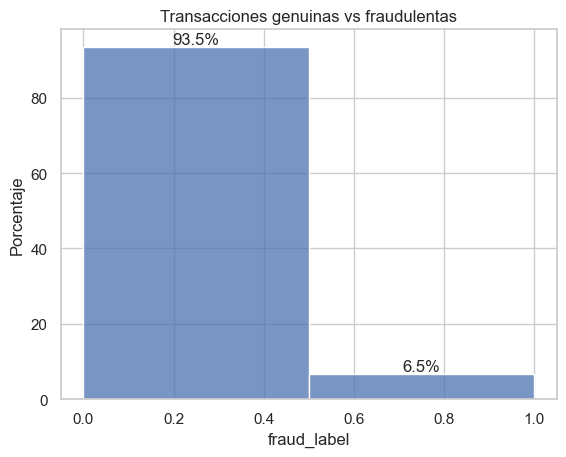

In [54]:
#Veamos que porcentaje de transacciones son reales vs fraudulentas
plt.title('Transacciones genuinas vs fraudulentas')
ax = sns.histplot(df['fraud_label'], bins=2, stat="percent")

# Agregamos el porcentaje a cada barra
for p in ax.patches:
    porcentaje = p.get_height()
    ax.annotate(f'{porcentaje:.1f}%', 
                (p.get_x() + p.get_width() / 2, porcentaje),
                ha='center', va='bottom')

plt.ylabel("Porcentaje")
plt.show()

En el gráfico anterior se puede visualizar que porcentaje de transacciones clasificadas como genuinas (0) y fraudulentas (1) dentro del dataset, se observa que aproximadamente 93.5% de las transacciones corresponden a operaciones reales operadas por los usuarios dueños de la cuenta, mientras que solo 6.5% han sido identificadas como fraudulentas.

Se puede ver que hay un desbalance en la variable objetivo, es una proporcion 6.5% de registros marcados como fraudulentos en relación del 100% del Dataset en modelos predictivos es complejo trabajar con este tipo de desbalance dado que las predicciones pueden inclinarse por datos de mayor porcentaje.

Después de los análisis realizados y conforme a las conclusiones e indicios nos planteamos aas siguiente preguntas en donde exploraremos la variable objetivo como se comporta con otras.

## Exploramos las variables a detalle


Tenemos algunas hipotesis iniciales, que vamos a ir analizando una a una, para lo cual vamos a desglosar las hipotesis con estas preguntas e ir concluyendo que variables parecen explicar si una transaccion será fraude o no. 

## Hipotesis:

### A. ¿La hora del día en la que se hace la transacción, tiene relación con la marcación de fraude?

Se podría pensar que las transacciones fraudulentas pueden ocurrir más en horas de la noche o madrugada.
Conforme a la pregunta realizaremos un histograma que valide cantidad de transaciones vs hora del dia  y generarmos una grafica de densidad donde se compare dichos datos entre transaciones correcta vs fraudulenteas haciendo uso de librerias como seaborn y matplotlib.


🔍  Histograma
----------------------------------------
fraud_label
0    0.9348
1    0.0652
Name: proportion, dtype: float64


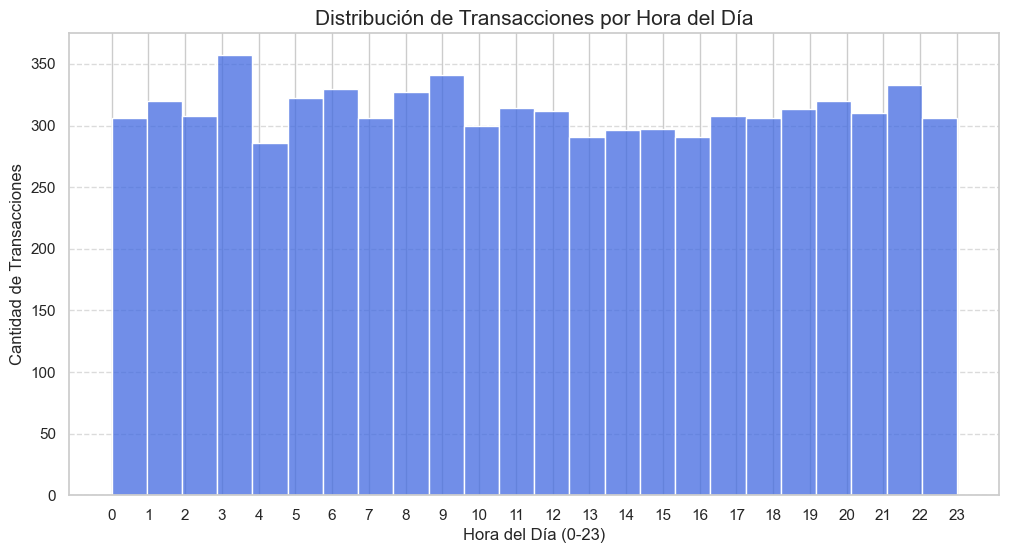


🔍  Grafico Densidad
----------------------------------------


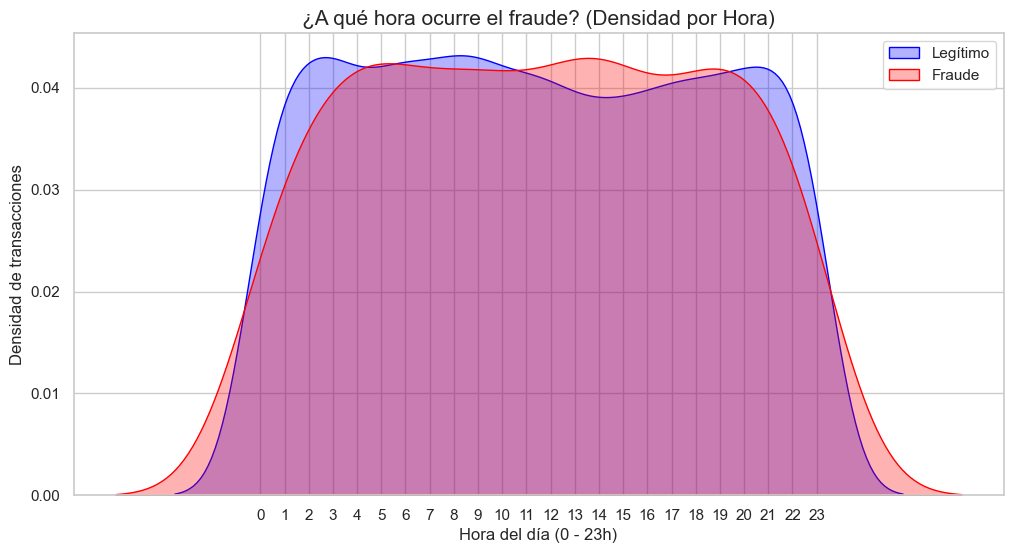

In [55]:

print("\n🔍  Histograma")
print("-" * 40)

# Revisamos las horas en las que hay datos de transacciones, y creamos histograma para ver como se distribuyen las transacciones
df['transaction_hour'].value_counts().sort_index()

print(df['fraud_label'].value_counts(normalize=True))


plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='transaction_hour', bins=24, kde=False, color='royalblue')
plt.title('Distribución de Transacciones por Hora del Día', fontsize=15)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(range(0, 24)) # Para que aparezcan todos los números del 0 al 23
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 1. Configuramos el estilo

print("\n🔍  Grafico Densidad")
print("-" * 40)
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de densidad para ver el comportamiento
plt.figure(figsize=(12, 6))

# Graficamos la distribución de la hora separando por fraude
sns.kdeplot(data=df[df['fraud_label'] == 0], x='transaction_hour', 
            label='Legítimo', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df[df['fraud_label'] == 1], x='transaction_hour', 
            label='Fraude', fill=True, color='red', alpha=0.3)

# 3. Personalización del gráfico
plt.title('¿A qué hora ocurre el fraude? (Densidad por Hora)', fontsize=15)
plt.xlabel('Hora del día (0 - 23h)')
plt.ylabel('Densidad de transacciones')
plt.xticks(range(0, 24))
plt.legend()
plt.show()






El histograma permite observar cómo se distribuye la cantidad de transacciones entre las 24 horas del día, el cual nos ayuda a identificar los momentos con mayor cantidad de transacciones dentro del sistema. Además, el gráfico de densidad compara la distribución de las horas entre transacciones reales y fraudulentas, permitiendo así identificar si existen diferencias en los patrones temporales de las diferentes operaciones.

Dado este resultado, queremos ver el comportamiento de la variable transacción hora, la cual nos permitirá ver, en qué horas aumenta la probabilidad de fraudes, aplicando una gráfica de probabilidad.



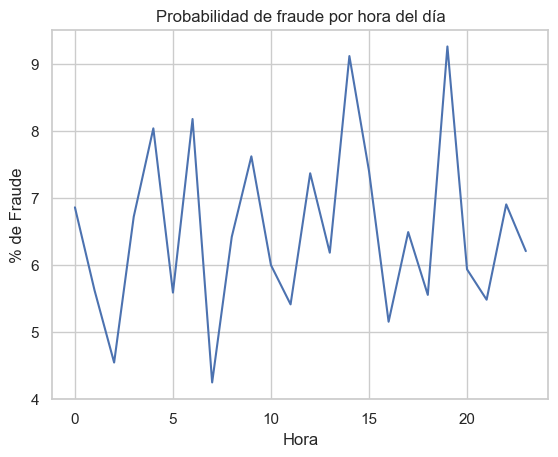

In [56]:
fraude_por_hora = df.groupby('transaction_hour')['fraud_label'].mean() * 100
fraude_por_hora

sns.lineplot(x=fraude_por_hora.index, y=fraude_por_hora.values)
plt.title("Probabilidad de fraude por hora del día")
plt.xlabel("Hora")
plt.ylabel("% de Fraude")
plt.show()

A partir del gráfico de probabilidad se observa que  fraude fluctúa entre aproximadamente 4% y 9% dependiendo de la hora del día. Aunque las variaciones no son evidentes, se identifican algunos momentos donde la probabilidad de que ocurra fraude aumenta , particularmente alrededor de ciertas horas del día donde el porcentaje supera el promedio general del dataset de 6.5%, se puede detallar en la línea azul que hay picos altos en la hora 14:00 y hora 19:00, esto en un contexto cotidiano asumiendo que son las 2pm, pueden aumentar dado que es hora de almuerzo, las personas aprovechamos para hacer pagos, hacer compras y en este alto flujo pueden pasar mas desapercibidos los fraudes, además a las 7:00pm  puede estar relacionado con el fin de la jornada laboral, cuando se realizan actividades personales como compras en línea, pagos o uso de aplicaciones financieras desde casa, además con un factor importante que el uso de los dispositivos es mal alto y estamos conectados a redes de nuestras casas lo que puede generar mayor exposición.

## 🏁 Conclusiones del Análisis Temporal

Tras analizar la distribución horaria de las transacciones y su relación con el fraude, se identifican los siguientes puntos clave:

* **Distribución General:** No se observa una correlación directa y fuerte entre la hora del día y la ocurrencia de fraude. Las transacciones fraudulentas están distribuidas de manera uniforme, siguiendo el flujo habitual del volumen transaccional.
* **Anomalía de Volumen:** Se detecta un pico de actividad inusual entre las **3:00 a.m. y 4:00 a.m.** Aunque no es un horario común para el usuario promedio, no concentra una tasa de fraude desproporcionada.
* **Análisis de Densidad:** * Existe un rango específico (**11:00 a.m. a 7:00 p.m.**) donde la densidad de transacciones fraudulentas supera ligeramente a las legítimas.
    * **Veredicto:** A pesar de este hallazgo, la diferencia no se considera un patrón lo suficientemente significativo como para determinar una franja horaria de alto riesgo por sí sola.

> **Nota:** El comportamiento del fraude en este dataset parece ser "mimético", es decir, intenta ocultarse dentro de los horarios de mayor actividad humana para pasar desapercibido.

### B. ¿Cómo se distribuye el monto de las transacciones?


Tenemos la hipótesis de que las transacciones fraudulentas deben ser por montos superiores a las transacciones legítimas. 
Queremos ver  con esta pregunta si la mayoría de las compras son pequeñas o grande vs la frecuencia de estas , y  si esto genera un patron en las transacciones fraudulentas, por lo cual realizaremos dos graficas mostrando el total de transacciones con una linea promedio del monto y otra con la grafica solo con datos de transacciones fraudulentas.

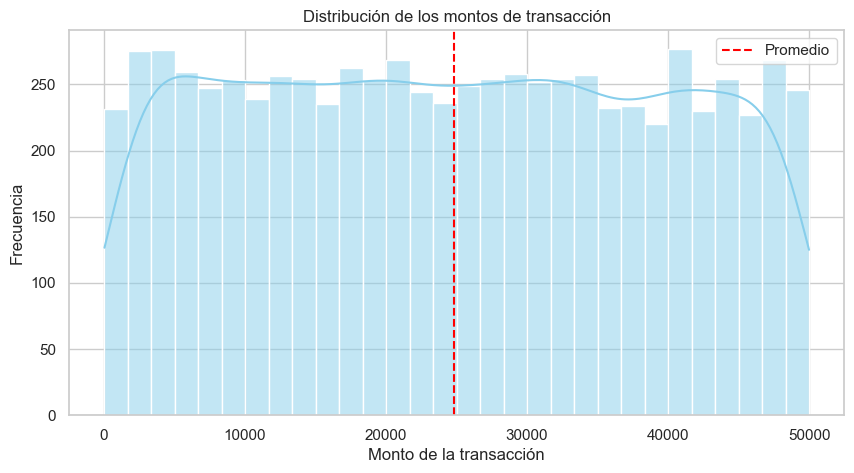

In [76]:
plt.figure(figsize=(10, 5))
sns.histplot(df['transaction_amount'], bins=30, kde=True, color='skyblue')

# Línea del promedio
plt.axvline(df['transaction_amount'].mean(), color='red', linestyle='--', label='Promedio')

plt.title('Distribución de los montos de transacción')
plt.xlabel('Monto de la transacción')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

El gráfico anterior nos permite visualizar la distribución de los montos de las transacciones. A partir del histograma se evidencia que los montos se distribuyen de forma relativamente uniforme entre aproximadamente 50 y 50.000 (Moneda), sin una valor marcado en un rango específico.

La línea punteada roja representa el promedio del monto de las transacciones, el cual se encuentra alrededor de los 24.800. Esto nos indica que, en promedio, las transacciones se ubican cerca del punto medio lo que nos detalla que no hay  atípicos o valores muy exagerados que sugieran un comportamiento irregular.

A simple vista no se observa que haya una concentración de transacciones en rangos de montos puntuales, vamos a revisar con un grafico de densidad cual es la distribucion de transacciones por monto comparando las fraudulentas vs legitimas

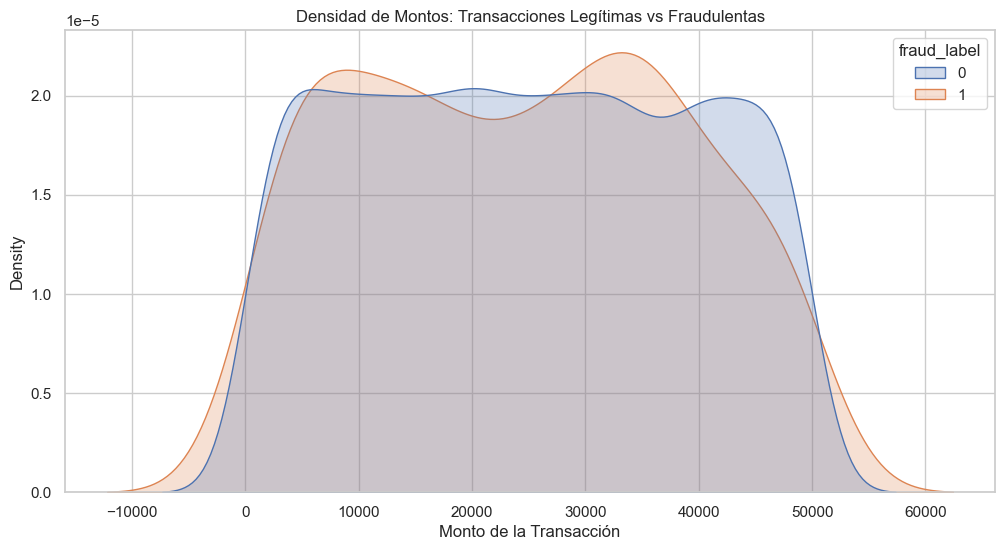

In [58]:
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x='transaction_amount', hue='fraud_label', common_norm=False, fill=True)
plt.title('Densidad de Montos: Transacciones Legítimas vs Fraudulentas')
plt.xlabel('Monto de la Transacción')
plt.show()

Notamos que las curvas se solapan casi por completo. Esto significa que el fraude no se oculta en montos inusualmente altos, sino que 'imita' el comportamiento del usuario promedio para pasar desapercibido.Sin embargo entre 30.000 y 40.000 se observa una mayor ocurrencia de transacciones con fraude.

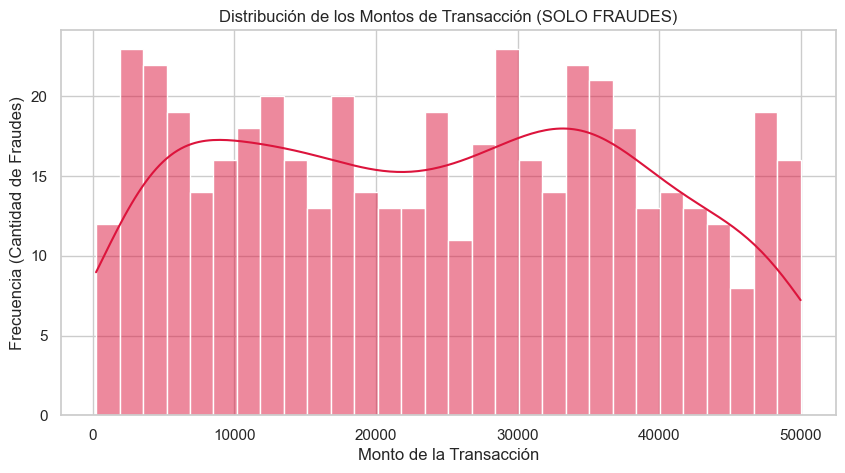

In [59]:
# Creamos un subconjunto de datos SOLO con los fraudes
df_fraude = df[df['fraud_label'] == 1]

# Generamos el gráfico
plt.figure(figsize=(10, 5))
sns.histplot(df_fraude['transaction_amount'], bins=30, kde=True, color='crimson')
plt.title('Distribución de los Montos de Transacción (SOLO FRAUDES)')
plt.xlabel('Monto de la Transacción')
plt.ylabel('Frecuencia (Cantidad de Fraudes)')
plt.show()

Al analizar únicamente las transacciones marcadas como fraude, se puede opbservar que los montos se distribuyen a lo largo de todo el rango de valores normal dentro del dataset, desde montos bajos hasta  50.000. La gráfica no muestra un dato evidente en un rango específico de valores, lo que nos da a entender que las transacciones fraudulentas pueden ocurrir tanto en cantidades de dinero pequeñas como altas.

#### 📑 Conclusiones: Análisis de Montos (Amount)

Tras evaluar la distribución de los montos tanto en transacciones legítimas como fraudulentas, se determinan los siguientes hallazgos:

* **Distribución de Frecuencia:** No se observa una concentración de fraude en rangos específicos; la distribución es **homogénea** a lo largo de todo el espectro económico.
* **Rango Operativo del Fraude:** Se identifican actividades ilícitas en un rango sumamente amplio, partiendo desde montos mínimos de **$245** hasta alcanzar el límite superior de **$50,000**.
* **Estrategia de Encubrimiento:** Los registros fraudulentos no presentan valores atípicos (outliers) extremos que los delaten fácilmente, sino que se encuentran **encubiertos** dentro de los registros verdaderos.

> **Hallazgo Clave:** El comportamiento del fraude en cuanto al monto es "espejo" del comportamiento legal. Esto sugiere que el fraude no busca vulnerar límites de transacciones altas, sino pasar desapercibido mediante montos comunes.

### C. ¿Como se comporta  la distribución de los score de riesgo en las transacciones ?


Queremos analizar el comprotamiento del Score de riesgo conforme a las transacciones verdaderas vs las fraudulentas, por lo cual graficaremos generando un groupby  mediante Boxplot que nos permitaver dicha comparativa.

Riesgo de IP promedio:
fraud_label
0    0.504771
1    0.508689
Name: ip_risk_score, dtype: float64


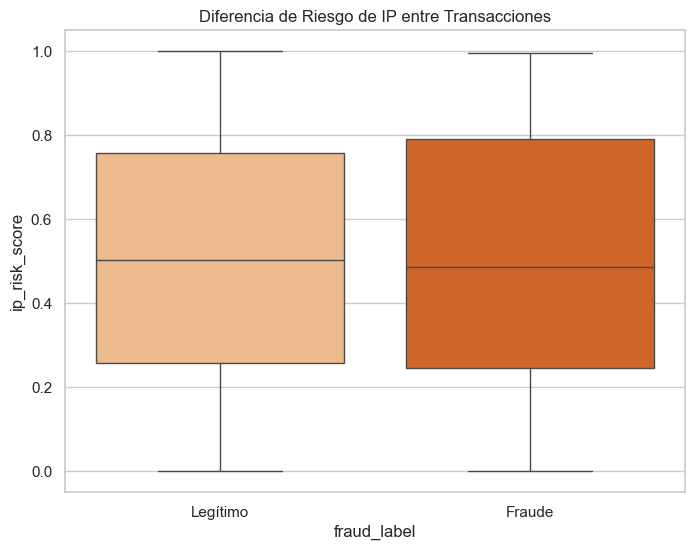

In [60]:
# Comparamos el riesgo promedio de IP entre transacciones normales y fraudes
promedio_riesgo = df.groupby('fraud_label')['ip_risk_score'].mean()
print("Riesgo de IP promedio:")
print(promedio_riesgo)

# Visualización de Boxplot para ver la diferencia clara
plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud_label', y='ip_risk_score', data=df, palette='Oranges')
plt.title('Diferencia de Riesgo de IP entre Transacciones')
plt.xticks([0, 1], ['Legítimo', 'Fraude'])
plt.show()

#### 📑 Conclusiones: Análisis de Riesgo por IP (Ip_risk_score)

Tras analizar los promedios numéricos y la distribución del riesgo asociado a las direcciones IP, se determinan los siguientes hallazgos:

* **Similitud Estadística:** Se observa una paridad casi absoluta entre los promedios de riesgo. Mientras que las transacciones legítimas presentan un riesgo promedio de **0.504**, las fraudulentas se sitúan en **0.508**.
* **Poder Predictivo Individual:** Debido a esta similitud, la variable por sí sola resulta **insuficiente** para predecir el fraude. No existe un umbral claro que permita diferenciar ambos comportamientos de manera lineal.
* **Mimetismo de Riesgo:** El análisis descarta reglas simples (como *"Riesgo > 0.8 = Fraude"*), ya que se identificaron numerosas transacciones legítimas con riesgo alto y, de igual forma, eventos de fraude originados desde IPs calificadas con riesgo bajo.

> **Hallazgo Clave:** El riesgo de IP no es un indicador determinante de forma aislada. Su valor real probablemente resida en la interacción con otras variables comportamentales, confirmando que los patrones de fraude en este dataset son altamente sofisticados y no dependen de una única señal tecnológica.

### D.¿Como se comporta  la distribución segun el tipo y medio de las transacciones ?

Validaremos el comportamiento a traves del porcentaje a nivel del tipo y medio de transaccion en un comparativo de transacciones reales vs fraudulentas para evidenciar si hay patrones que nos indiquen el fraude, realizaremos dos graficas de barras por tipo de pago y medio de las transacciones y un dataframe con el porcentaje de las transacciones fraudulentas.

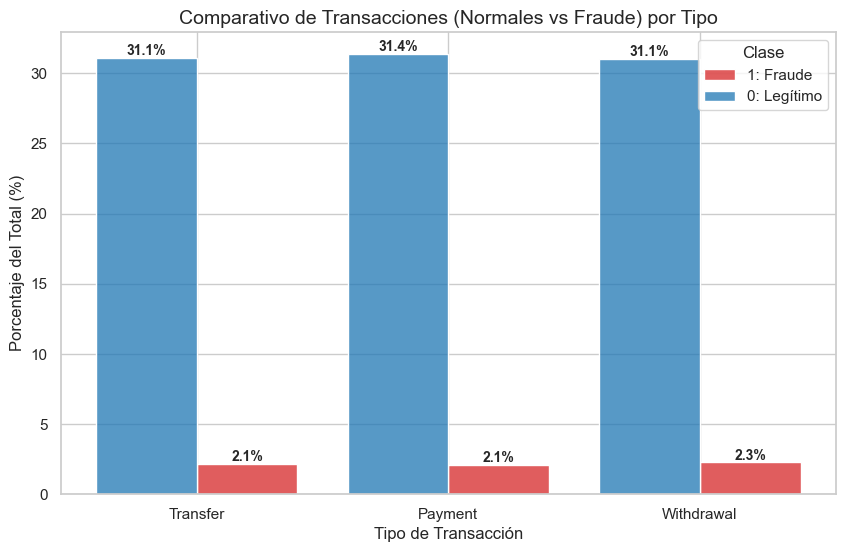

In [61]:

# 1. Generar el gráfico
plt.figure(figsize=(10, 6))
plt.title('Comparativo de Transacciones (Normales vs Fraude) por Tipo', fontsize=14)

# OJO: Aquí usamos 'df_grafico' en lugar de 'df'
ax = sns.histplot(
    data=df, 
    x='transaction_type', 
    hue='fraud_label', 
    stat="percent", 
    multiple="dodge", 
    shrink=0.8,
    palette=['#1f77b4', '#d62728'] # Azul para Legítimo, Rojo para Fraude
)

# 2. Ciclo for para añadir los porcentajes encima de cada barra
for p in ax.patches:
    porcentaje = p.get_height()
    # Solo anotamos si la barra tiene altura mayor a 0
    if porcentaje > 0:
        ax.annotate(f'{porcentaje:.1f}%', 
                    (p.get_x() + p.get_width() / 2., porcentaje),
                    ha='center', 
                    va='bottom',
                    fontsize=10,
                    fontweight='bold')

plt.xlabel('Tipo de Transacción', fontsize=12)
plt.ylabel('Porcentaje del Total (%)', fontsize=12)

# Ajustar la leyenda
plt.legend(title='Clase', labels=['1: Fraude', '0: Legítimo'])

plt.show()

Luego de analizar el gráfico podemos identificar que las transacciones legítimas (barra de color azul) se distribuyen de forma muy similar entre los tres tipos, esto nos indica que no existe una concentración clara de la cantidad  de transacciones en un solo tipo lo que sugiere que el tipo de operación por sí solo no es un indicador fuerte de fraude en el dataset.

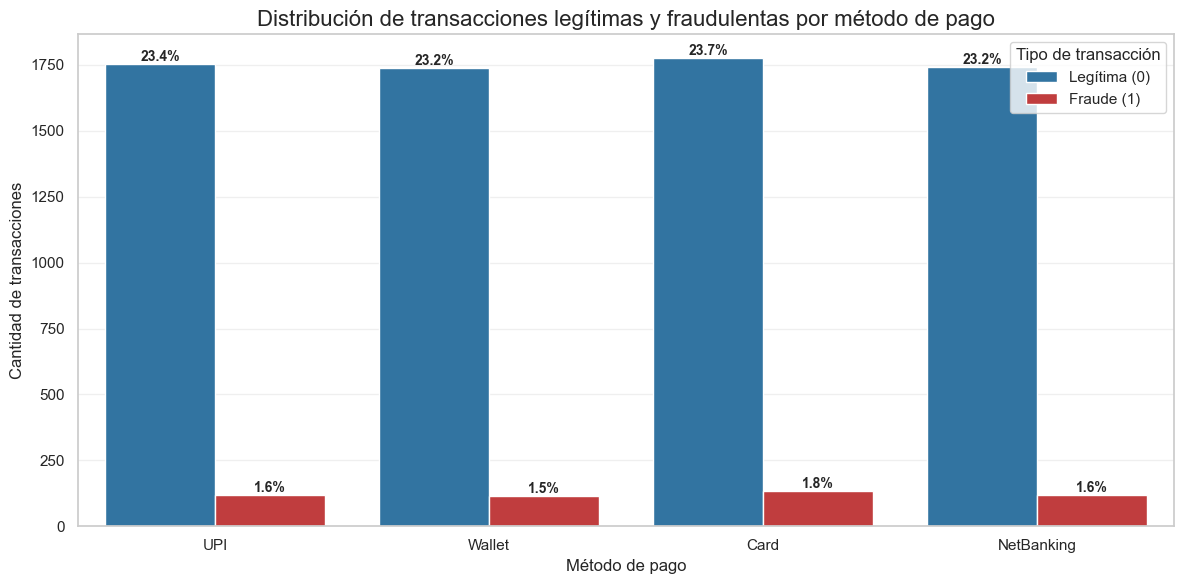

In [77]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x="payment_mode",
    hue="fraud_label",
    hue_order=[0,1],  # asegura orden correcto
    palette=["#1f77b4", "#d62728"]  # azul legítimo, rojo fraude
)

# Títulos
plt.title("Distribución de transacciones legítimas y fraudulentas por método de pago", fontsize=16)
plt.xlabel("Método de pago", fontsize=12)
plt.ylabel("Cantidad de transacciones", fontsize=12)

# Ajustar leyenda
plt.legend(title="Tipo de transacción", labels=["Legítima (0)", "Fraude (1)"])

# Grid para mejor lectura
plt.grid(axis="y", alpha=0.3)

# Añadir porcentajes sobre las barras
total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    
    if height > 0:
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center',
                    va='bottom',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()

Luego de analizar el gráfico de barras enfocado a la variable de medio de pago, podemos identificar que las transacciones reales o legítimas se compartan muy similar, aunque el método "Card" registra una proporción ligeramente mayor de fraude, las diferencias entre métodos son mínimas, lo que sugiere que el método de pago por sí solo no contribuye a un indicador fuerte de fraude dentro del conjunto de datos.

In [63]:
# 1. Calculamos el porcentaje de fraude por cada tipo de pago
tabla_fraude = df.groupby('payment_mode')['fraud_label'].mean() * 100

tabla_fraude = tabla_fraude.reset_index()

# 2. Renombramos las columnas para que sean claras
tabla_fraude.columns = ['Método de Pago', '% de Fraude']

# 3. Ordenamos de mayor a menor riesgo
tabla_fraude = tabla_fraude.sort_values(by='% de Fraude', ascending=False)

# 4. Mostramos la tabla con un estilo limpio
print("--- Porcentaje de Fraude por Método de Pago ---")
display(tabla_fraude)

--- Porcentaje de Fraude por Método de Pago ---


,Método de Pago,% de Fraude
0,Card,7.060669
1,NetBanking,6.444683
2,UPI,6.403415
3,Wallet,6.155508




#### 📑 Conclusión: Medios de Pago y Tipos de Transacción

* **Análisis de Probabilidad:** La tabla de porcentaje de fraude por medio de pago nos indica que hay mayor probabilidad cuando se usan tarjetas para realizar pagos dado que es de **7.06%**. Algo que tiene sentido dado que las tarjetas suelen utilizarse en entornos digitales o transacciones remotas, donde los controles de autenticación y seguridad pueden ser saltados.

* **Volumen vs. Proporción:** La cantidad de transacciones por tipo de transaccion en el volumen general de operaciones, la gran mayoría de todas las transacciones son **"Pagos" (Payments)** y **"Transferencias" (Transfers)**. 

* **Distribución del Fraude:** Sin embargo, la proporción de fraude se distribuye de manera muy similar y paralela entre los tres tipos de transacciones (Payment, Transfer y Withdrawal) destacando minimamente los **retiros** en mayor porcentaje, algo que en los analisis anteriores no habiamos visualizado.

* **Seguridad de los Métodos:** En cuanto al medio de pago no tienen una concentración de fraude en algun item puntual, sin embargo el porcentaje más alto de fraudes está en **tarjeta de crédito** y el más seguro es **wallet** sin ser un dato que destaque totalmente de los otros metodos.

### E. ¿ La disitribuccion geografica del Dataset tiene alguna incidencia el la generacion de fraudes y como se comporta?

Para realizar el analisis de esta pregunta ,realizaremos incialmente uso del metodo unique para ver las ciudades existentes en la data y  realizaremos un conteo de su distribucion entre nacional e internacional , posteriomente crearemos un dataframe el cual nos muestre el porcentaje de participacion por ciudad de registros fraudulentos que se completmente con una grafica  que marque la media de registros globales con fraude , tambien haremos una grafica de torta con la participacion de transaciones nacionales e internacionales  y por ultimo un dataframe y grafica  revisando como se comporta el riesgo en relacion con la localizacion.

--- Ranking de Riesgo por Ciudad ---


,Ciudad,% de Fraude
0,Mumbai,7.308743
1,Hyderabad,7.125155
2,Chennai,6.198910
3,Bangalore,6.126482
4,Delhi,5.779944


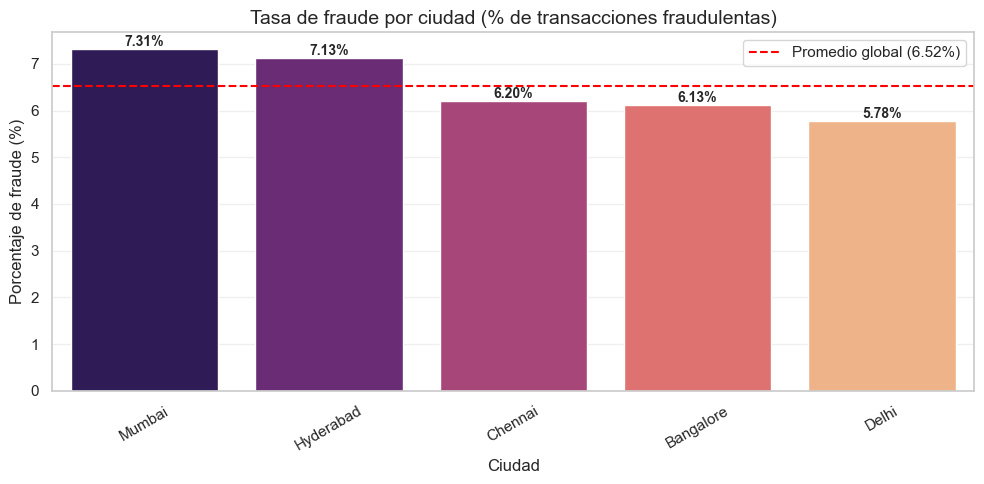

In [78]:
# Calcular el % de fraude por ciudad
fraude_ciudad = df.groupby('device_location')['fraud_label'].mean() * 100
fraude_ciudad = fraude_ciudad.sort_values(ascending=False).reset_index()
fraude_ciudad.columns = ['Ciudad', '% de Fraude']

print("--- Ranking de Riesgo por Ciudad ---")
display(fraude_ciudad)

# Promedio global de fraude
fraude_global = df['fraud_label'].mean() * 100

# Gráfico
plt.figure(figsize=(10,5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=fraude_ciudad,
    x='Ciudad',
    y='% de Fraude',
    hue='Ciudad',          # evita el warning de seaborn
    palette='magma',
    order=fraude_ciudad['Ciudad'],
    legend=False
)

plt.title('Tasa de fraude por ciudad (% de transacciones fraudulentas)', fontsize=14)
plt.xlabel('Ciudad')
plt.ylabel('Porcentaje de fraude (%)')

# Línea del promedio global
plt.axhline(
    fraude_global,
    color='red',
    linestyle='--',
    label=f'Promedio global ({fraude_global:.2f}%)'
)

# Añadir etiquetas de porcentaje
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

--- Ranking de Riesgo por Ciudad ---


,Ciudad,% de Fraude
0,Mumbai,7.308743
1,Hyderabad,7.125155
2,Chennai,6.198910
3,Bangalore,6.126482
4,Delhi,5.779944


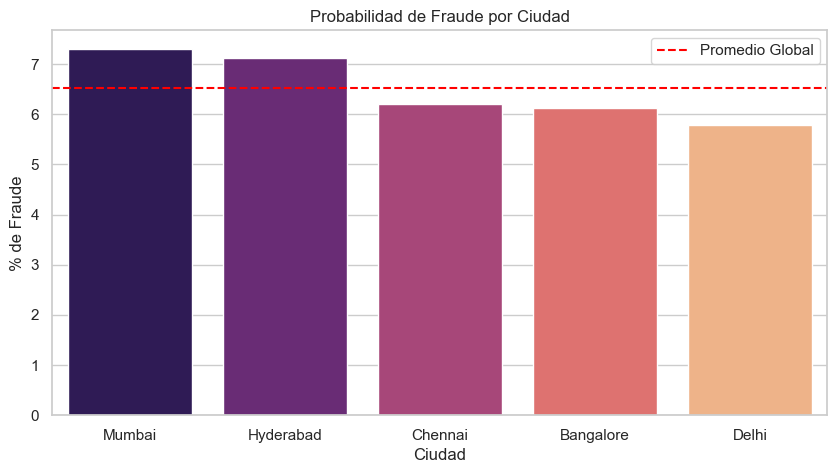

In [65]:
# Calcular el % de fraude por ciudad
fraude_ciudad = df.groupby('device_location')['fraud_label'].mean() * 100
fraude_ciudad = fraude_ciudad.sort_values(ascending=False).reset_index()
fraude_ciudad.columns = ['Ciudad', '% de Fraude']

print("--- Ranking de Riesgo por Ciudad ---")
display(fraude_ciudad)

# Gráfico de barras para comparar
plt.figure(figsize=(10, 5))
sns.barplot(data=fraude_ciudad, x='Ciudad', y='% de Fraude', palette='magma')
plt.title('Probabilidad de Fraude por Ciudad')
plt.axhline(df['fraud_label'].mean()*100, color='red', linestyle='--', label='Promedio Global')
plt.legend()
plt.show()

Luego de observar la gráfica anterior, podemos analizar que que Mumbai 'Barra de color morado' (7.31%) y Hyderabad 'Barra de color violeta' (7.13%) presentan los niveles más altos de fraude, situándose por encima del promedio global (6.52%), muy por el contrario Delhi 'Barra de color naranja claro' que representa el porcentaje mas bajo 5.78% , pero cabe resaltar que los porcentajes en comparación no son extramadamente diferentes como para definir que la Ciudad es un factor determinante en el fraude.

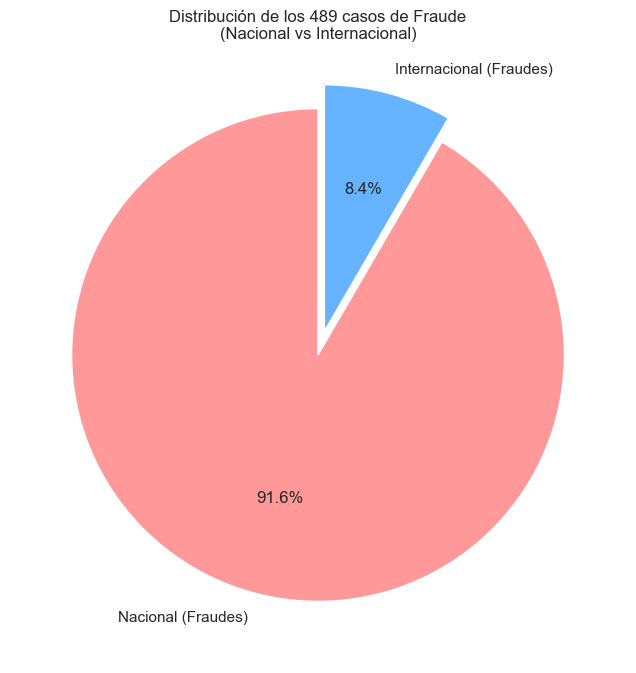

Cantidad exacta de fraudes:
Nacional (Fraudes)         448
Internacional (Fraudes)     41
dtype: int64


In [66]:
# Veamos si el fraude es más alto en transacciones internacionales
solo_fraude = df[df['fraud_label'] == 1]

# 2. Contamos cuántos hay por cada tipo (nacional vs internacional)
conteo_fraude_intl = solo_fraude.groupby('is_international').size()

# 3. Cambiamos los nombres de los índices para que el gráfico sea legible
conteo_fraude_intl.index = ['Nacional (Fraudes)', 'Internacional (Fraudes)']

# 4. Graficamos la proporción de ese "universo" de fraudes
plt.figure(figsize=(8, 8))
plt.pie(conteo_fraude_intl, 
        labels=conteo_fraude_intl.index, 
        autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], 
        startangle=90,
        explode=(0, 0.1))

plt.title('Distribución de los 489 casos de Fraude\n(Nacional vs Internacional)')
plt.show()


print("Cantidad exacta de fraudes:")
print(conteo_fraude_intl)

Luego de analizar el gráfico circular o de Torta, podemos identificar que la sección de color naranja representa las transacciones nacionales con un porcentaje del 91.6%, mientras que la sección de color azul representa solo el 8.4%, de la cual podemos concluir que en este dataset la mayor parte de registros corresponden a transacciones nacionales, lo cual no es un dataset apropiado para compararar la variable y determinar que el fraude en su gran mayoría ocurre a nivel nacional, porque la información de transacciones internacionales es casi nula.

--- Análisis de Riesgo: Nacional vs Internacional ---


,Total Transacciones,% de Riesgo (Fraude)
Nacional,6745,6.641957
Internacional,755,5.430464


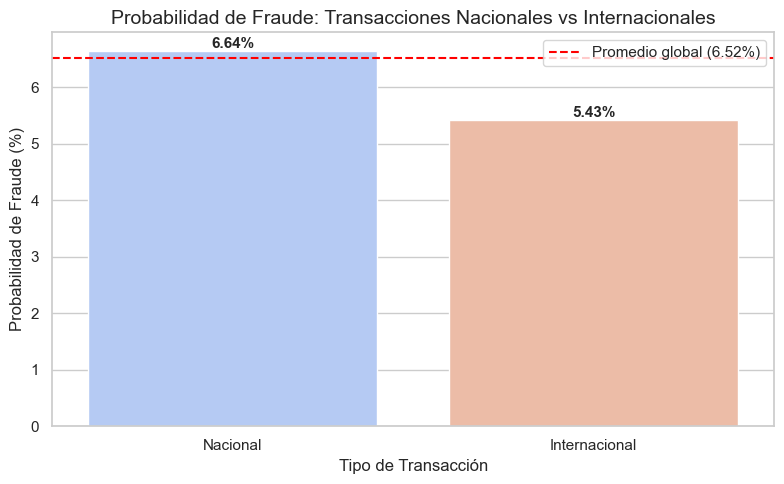

In [79]:
# 1. Crear tabla de riesgo
tabla_riesgo = df.groupby('is_international')['fraud_label'].agg(['count', 'mean'])

# 2. Formatear tabla
tabla_riesgo['mean'] = tabla_riesgo['mean'] * 100
tabla_riesgo.columns = ['Total Transacciones', '% de Riesgo (Fraude)']
tabla_riesgo.index = ['Nacional', 'Internacional']

print("--- Análisis de Riesgo: Nacional vs Internacional ---")
display(tabla_riesgo)

# 3. Convertir a dataframe para seaborn
tabla_plot = tabla_riesgo.reset_index()
tabla_plot.columns = ['Tipo de Transacción', 'Total Transacciones', '% de Riesgo (Fraude)']

# Promedio global de fraude
promedio_global = df['fraud_label'].mean() * 100

# 4. Gráfico
plt.figure(figsize=(8,5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=tabla_plot,
    x='Tipo de Transacción',
    y='% de Riesgo (Fraude)',
    hue='Tipo de Transacción',
    palette='coolwarm',
    legend=False
)

# 5. Etiquetas de porcentaje sobre las barras
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.2f}%',
                (p.get_x() + p.get_width()/2, altura),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

# 6. Línea promedio global
plt.axhline(promedio_global,
            color='red',
            linestyle='--',
            label=f'Promedio global ({promedio_global:.2f}%)')

plt.title('Probabilidad de Fraude: Transacciones Nacionales vs Internacionales', fontsize=14)
plt.xlabel('Tipo de Transacción')
plt.ylabel('Probabilidad de Fraude (%)')

plt.legend()
plt.tight_layout()
plt.show()

#### 📑 Conclusión: Análisis Geográfico y Naturaleza de las Transacciones

* **Distribución por Ciudades:** El dataset se compone exclusivamente de ciudades de la India. Se observa que existen dos ubicaciones donde la incidencia de fraude es levemente superior al resto del país: **Mumbai** y **Hyderabad**.

* **Transacciones Internacionales vs. Nacionales:** Contrario a la creencia popular, las transacciones internacionales presentan un riesgo de fraude un **18% menor** que las transacciones nacionales (**5.43%** frente a **6.64%**). 

* **Efectividad de Controles:** Este hallazgo sugiere que los mecanismos de seguridad para pagos extranjeros son efectivos o que el patrón de ataque está enfocado en el mercado interno de India, principalmente en las dos ciudades anteriormente mencionadas.

### F. ¿Los intentos de login o la antiguedad de la cuenta se relacionan de forma positiva con el fraude?

Validaremos si el inteto de login y la antiguedad de la cuenta nos pueden brindar un patron para identificar las transacciones fraudulentas, haremos una agrupacion para ver el promedio de intentos de login entre las transacciones reales vs fraudulentas, adicional realizaremos un boxplot con una tabla para ver en comparativo de las transaciones  tanto de login  como antiguedad de las cuentas.

In [68]:
# Comparamos el promedio de intentos de login entre transacciones reales y fraude
intentos_login = df.groupby('fraud_label')['login_attempts_last_24h'].mean()
print("Promedio de intentos de login en las últimas 24h:")
print(intentos_login)

Promedio de intentos de login en las últimas 24h:
fraud_label
0    4.983882
1    5.155419
Name: login_attempts_last_24h, dtype: float64


--- VALORES EXACTOS DE LAS CAJAS (BOXPLOTS) ---


login_attempts_last_24h                     account_age_days  \
                                min  25%  50%  75%  max              min   
fraud_label                                                                
0                               1.0  3.0  5.0  7.0  9.0             10.0   
1                               1.0  3.0  5.0  7.0  9.0             10.0   

                                            
               25%     50%     75%     max  
fraud_label                                 
0            497.0  1012.0  1495.0  1999.0  
1            564.0  1108.0  1566.0  1996.0

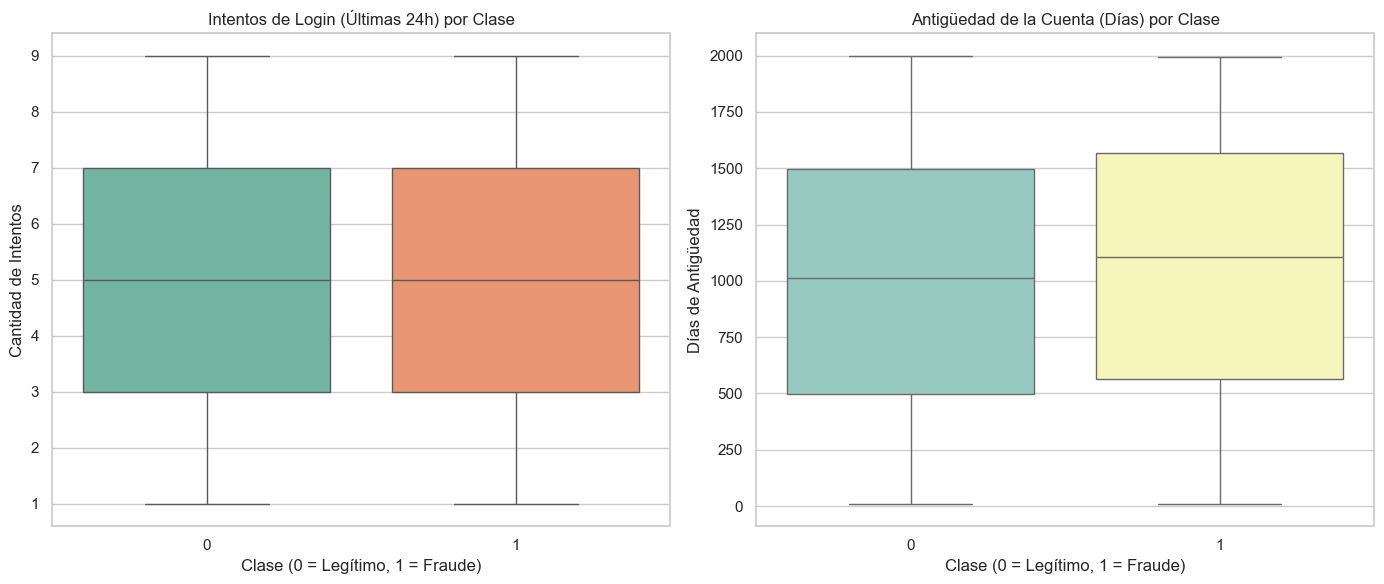

In [69]:

# Asumiendo que tu DataFrame ya está cargado en la variable 'df'

# 1. Seleccionamos las dos variables que graficamos
columnas = ['login_attempts_last_24h', 'account_age_days']

# 2. Agrupamos por clase de fraude y sacamos las estadísticas
estadisticas = df.groupby('fraud_label')[columnas].describe()

# 3. Filtramos para mostrar solo los 5 valores que componen un Boxplot
# (Quitamos el conteo, el promedio y la desviación estándar)
valores_boxplot = estadisticas.loc[:, (slice(None), ['min', '25%', '50%', '75%', 'max'])]

# 4. Mostramos la tabla formateada (usamos 'display' que se ve mejor en Jupyter que 'print')
print("--- VALORES EXACTOS DE LAS CAJAS (BOXPLOTS) ---")
display(valores_boxplot)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Intentos de Login vs Fraude
sns.boxplot(ax=axes[0], data=df, x='fraud_label', y='login_attempts_last_24h', hue='fraud_label', palette='Set2', legend=False)
axes[0].set_title('Intentos de Login (Últimas 24h) por Clase')
axes[0].set_xlabel('Clase (0 = Legítimo, 1 = Fraude)')
axes[0].set_ylabel('Cantidad de Intentos')

# Gráfico 2: Antigüedad de la Cuenta vs Fraude
sns.boxplot(ax=axes[1], data=df, x='fraud_label', y='account_age_days', hue='fraud_label', palette='Set3', legend=False)
axes[1].set_title('Antigüedad de la Cuenta (Días) por Clase')
axes[1].set_xlabel('Clase (0 = Legítimo, 1 = Fraude)')
axes[1].set_ylabel('Días de Antigüedad')

plt.tight_layout()
plt.show()

#### Conclusión
Tenemos un promedio levemente mayor de intentos de login en fraude vs transacciones genuinas lo que quiere decir que un alto número de intentos de login en las últimas 24 horas no es un indicador determinante de fraude por sí solo, con los mínimos y máximos de 1 a 9 intentos iguales en ambos grupos , en cuanto a la antiguedad se esperaría que el fraude viniera de cuentas nuevas creadas recientemente, pero los datos muestran que las cuentas donde hubo fraude tienen un promedio de 1071 días de antigüedad, mientras que las transacciones normales promedian los 1002 días no siendo un factor determinante por si solos el login o la antiguedad de la cuenta.

### G. ¿como se comporta la Correlacion de las Variables y su dispersion ?

En el ultimo análisis que aplicaremos corresponde a una correlación de las variables numéricas para determinar como se comportan conforme a nuestra variable objetivo, por lo cual haremos un mapa de calor  y un gráfico de las transaciones totales  vs el monto promedio.

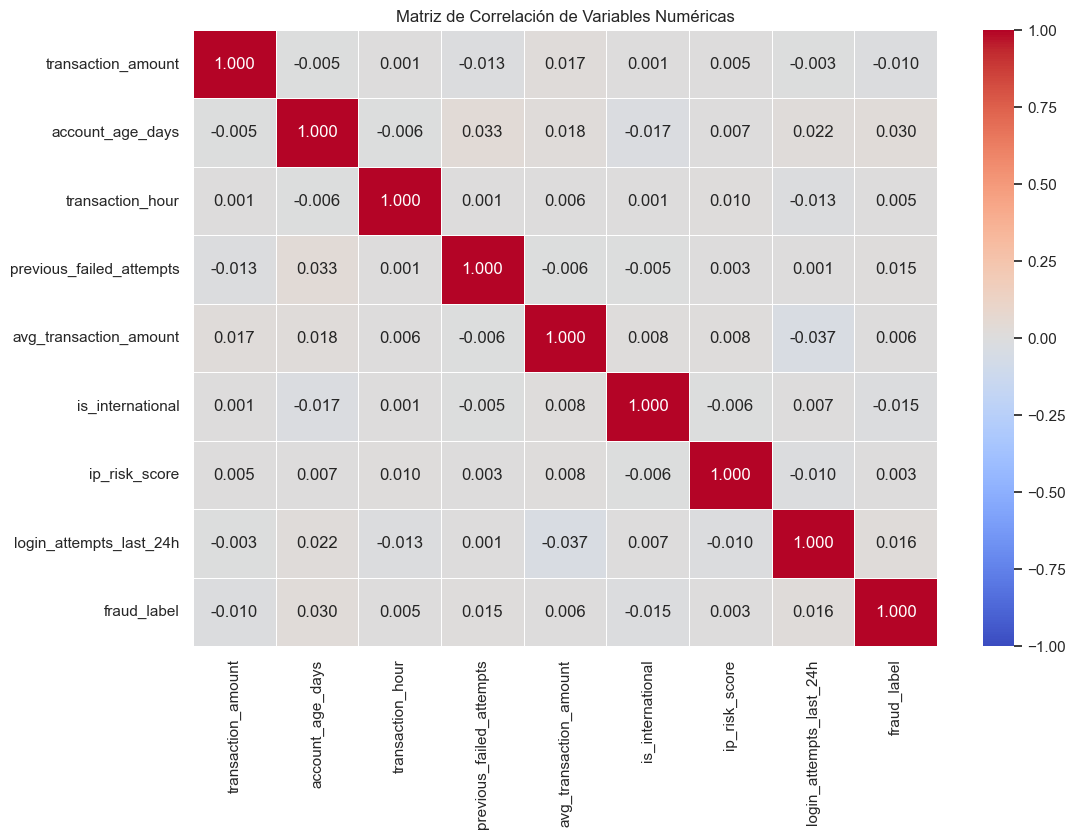

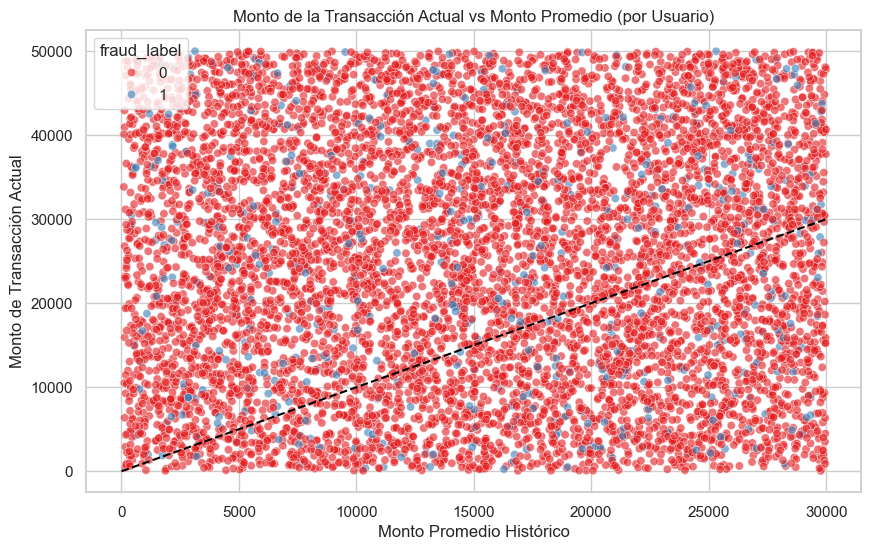

In [70]:
#1. Matriz de Correlación (Variables Numéricas)
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# 2. Análisis Multivariado: Relación Monto Actual vs Monto Promedio Histórico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_transaction_amount', y='transaction_amount', hue='fraud_label', alpha=0.6, palette='Set1')
plt.title('Monto de la Transacción Actual vs Monto Promedio (por Usuario)')
plt.xlabel('Monto Promedio Histórico')
plt.ylabel('Monto de Transacción Actual')
plt.plot([0, df['avg_transaction_amount'].max()], [0, df['avg_transaction_amount'].max()], color='black', linestyle='--') # Línea de ratio 1:1
plt.show()


#### 📑 Conclusión: Análisis de Correlación y Patrones de Camuflaje

* **Correlaciones Lineales:** Este gráfico de dispersión básicamente nos indica que no hay correlaciones lineales fuertes entre las variables numéricas simples y el fraude. La correlación más "alta" es **`account_age_days`** (apenas un **0.029** positivo), lo cual es un porcentaje muy bajo como lo muestra el mapa de calor.

* **Naturaleza del Fraude:** Adicional podemos analizar en el gráfico que los fraudes están completamente **mezclados y camuflados** como transacciones reales o genuinas, sin poder identificar un patrón real que determine cuándo una transacción es fraudulenta.

* **Hipótesis del Comportamiento:** Esto puede ocurrir dado que la mayoría de las veces las transacciones de "fraude" son realizadas correctamente, solo que por personas malintencionadas que suplantan identidades, clonan tarjetas o cuentas. 

> **Hallazgo Clave:** Debido a que las transacciones fraudulentas imitan a las reales, la detección se hace difícil. La inclinación del análisis va más enfocada a comparar con **patrones comportamentales** de los usuarios, los dueños-clientes reales de las cuentas.

No hay correlaciones lineales fuertes entre las variables numéricas simples y el fraude.La correlación más "alta" es account_age_days (apenas un 0.029 positivo) como lo muestra el mapa de calor Y en el grafico de dispersion muestra que los fraudes están completamente mezclados con las transacciones genuinas sin un patron definido.

# 4.Feature Engineering (Ingeniería de Características)

Debido a que no encontramos una alta correlación en estas variables por si solas, queremos analizar si combinando algunas variables se identifica un comportamiento diferente

Vamos a usar 3:

1. Ratio de gasto: Indica cuantas veces es mas grande o más pequeña la transaccion actual comparada con el promedio que el usuario suele gastar normalmente. si el valor nos da 1, nos dice que el usuario esta gastando exactamente lo mismo, es decir que esta en su promedio normal, a medida que el número es más alto significa que está gastando más de su promedio. 
2. Score de intrusión: Es la suma de los intentos y los logeos que tuvo el usuario. Sumamos los intentos fallidos y los logins y queremos validar si numeros mas altos estan relacionados con fraude.
3. Nuevas cuentas: aqui vamos a marcar como cuentas nuevas las que tengan menos de 30 dias, queremos identificar si las cuentas nuevas son mas peligrosas que las mas antiguas, ya que podrían ser abiertas para cometer fraudes.

In [71]:
# 1. Ratio de Gasto: ¿Está gastando más de su promedio habitual?
df['Amount_to_Avg_Ratio'] = df['transaction_amount'] / df['avg_transaction_amount']
# 2. Score de Intrusión: Combinamos intentos fallidos y actividad reciente
df['Intrusion_Score'] = df['previous_failed_attempts'] + df['login_attempts_last_24h']
# 3. Flag de Cuenta Nueva: Las cuentas recién creadas suelen ser más riesgosas
df['Is_New_Account'] = (df['account_age_days'] < 30).astype(int)

print("Nuevas variables creadas: 'Amount_to_Avg_Ratio', 'Intrusion_Score' y 'Is_New_Account'.")
df[['Amount_to_Avg_Ratio', 'Intrusion_Score', 'fraud_label', 'Is_New_Account']].sample(5)


Nuevas variables creadas: 'Amount_to_Avg_Ratio', 'Intrusion_Score' y 'Is_New_Account'.


,Amount_to_Avg_Ratio,Intrusion_Score,fraud_label,Is_New_Account
1771,2.285909,4,0,0
1167,0.933520,11,0,0
2988,1.447408,6,1,0
3123,145.839396,8,0,0
343,1.030282,5,0,0


In [72]:
# Comparamos cómo se ven nuestras nuevas variables para transacciones Legítimas (0) vs Fraude (1)
analisis_nuevas_vars = df.groupby('fraud_label')[['Amount_to_Avg_Ratio', 'Intrusion_Score', 'Is_New_Account']].mean()

print("Promedios según el tipo de transacción:")
display(analisis_nuevas_vars)

Promedios según el tipo de transacción:


,Amount_to_Avg_Ratio,Intrusion_Score,Is_New_Account
fraud_label,,,
0,4.424543,6.991727,0.009842
1,3.940018,7.251534,0.012270


Seguimos observando el patrón de que las transacciones fraudulentas no son por montos superiores al promedio normal de transacciones legitimas (4.4 vs 3.9) las transacciones legitimas tienen montos superiores a las transacciones fraudulentas. Confirmamos que al hacer estas transacciones fraudulentas la idea no es vaciar la cuenta sino ir poco a poco. 

Es interesante que para las transacciones fraudulentas, al combinar los intentos fallidos de login y el login en las ultimas 24 horas, en las transacciones fraudulentas es levemente mayor (6.99 vs 7.25) lo que nos indica que puede haber una diferencia al revisar la actividad general de los estafadores vs usuarios reales.

También se observa diferencia entre la antiguedad de la cuenta, recordemos que aqui tomamos solo las cuentas que lleven menos de 30 dias de creadas como cuentas nuevas.  En los fraudes si se observa que hay mas cuentas marcadas como nuevas (el numero es mas grande)

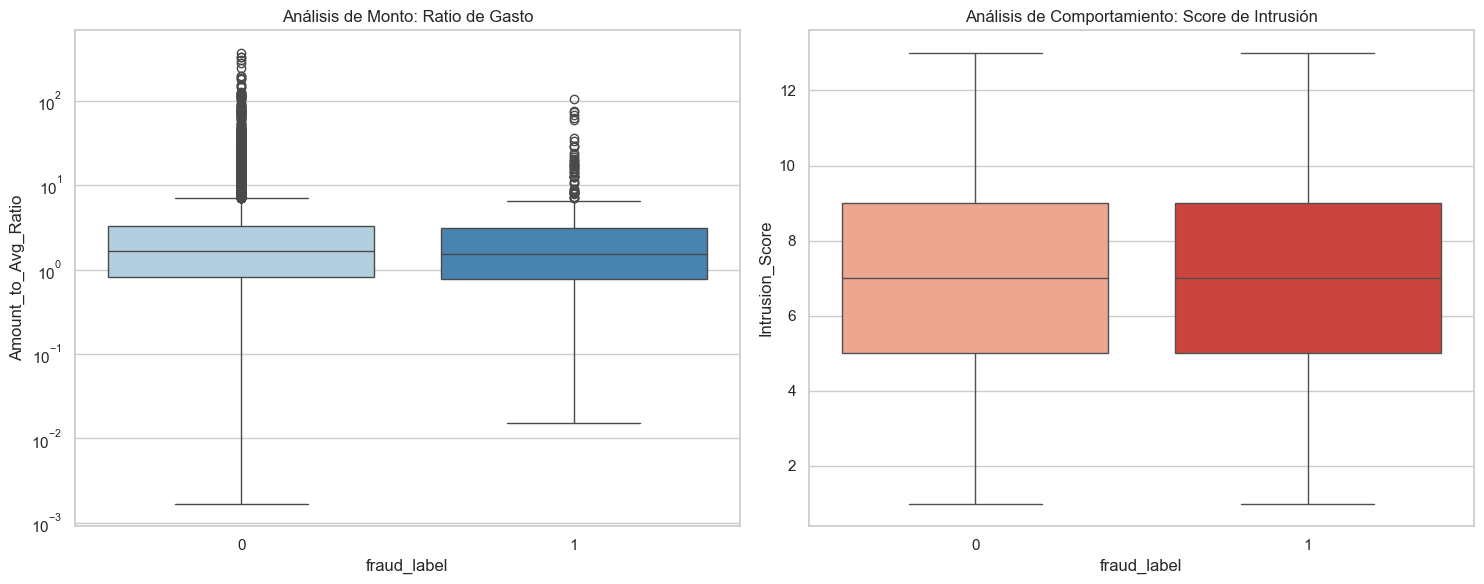

In [73]:
plt.figure(figsize=(15, 6))

# Subplot 1: Ratio de Gasto
plt.subplot(1, 2, 1)
sns.boxplot(x='fraud_label', y='Amount_to_Avg_Ratio', data=df, palette='Blues')
plt.title('Análisis de Monto: Ratio de Gasto')
plt.yscale('log') # Escala logarítmica para manejar valores extremos

# Subplot 2: Score de Intrusión
plt.subplot(1, 2, 2)
sns.boxplot(x='fraud_label', y='Intrusion_Score', data=df, palette='Reds')
plt.title('Análisis de Comportamiento: Score de Intrusión')

plt.tight_layout()
plt.show()

In [74]:
# Calculamos percentiles específicos para ambas clases
percentiles = [25, 50, 75, 90, 95, 99]

tabla_percentiles = df.groupby('fraud_label')['Intrusion_Score'].quantile([p/100 for p in percentiles]).unstack()
tabla_percentiles.columns = [f'P{p}' for p in percentiles]

print("Comparación de Percentiles: Intrusion_Score")
display(tabla_percentiles)

Comparación de Percentiles: Intrusion_Score


,P25,P50,P75,P90,P95,P99
fraud_label,,,,,,
0,5.0,7.0,9.0,11.0,12.0,13.0
1,5.0,7.0,9.0,11.0,12.0,13.0


Conclusión del Análisis de Distribución (Boxplots)
Al comparar las distribuciones del Ratio de Gasto y el Score de Intrusión, el análisis nos revela una verdad contraintuitiva sobre el fraude en este dataset:

1. Mimetismo en el Gasto: El boxplot de Amount_to_Avg_Ratio muestra cajas casi solapadas. Esto confirma que el defraudador promedio es cauteloso ya que  no realiza gastos exorbitantes que rompan el perfil del usuario, incluso la mediana de fraude es ligeramente menor a la legitima. Por lo tanto, el monto de la transacción por sí solo es un predictor débil.

2. Al analizar los percentiles de la variable Intrusion_Score, descubrimos un comportamiento espejo: el 95% de las transacciones fraudulentas tienen 12 o menos intentos, exactamente igual que las transacciones legítimas.

Variable de Soporte, no de Decisión: Esta variable, por sí sola, no puede ser una regla de bloqueo. Si bloqueamos a alguien por tener 13 intentos (Percentil 99), estaríamos afectando a la misma proporción de clientes buenos que de criminales."



**Conclusion:**

Interpretación de las Nuevas Señales de Riesgo
Al agrupar los datos por la etiqueta de fraude, los números nos cuentan una historia muy interesante sobre el comportamiento de las transacciones en este dataset:

1. El Mito del Gasto Excesivo (Amount_to_Avg_Ratio):

Resultado: Las transacciones legítimas (0) tienen un ratio promedio de 4.42, mientras que las fraudulentas (1) tienen un ratio menor de 3.94.

Conclusión: Los defraudadores en este ecosistema son cautelosos. No están intentando vaciar la cuenta de un solo golpe con montos astronómicos comparados al historial, prefieren montos que parezcan "normales" o incluso ligeramente inferiores al promedio para evitar activar las alarmas automáticas de los bancos.

2. El Patrón de Insistencia (Intrusion_Score):

Resultado: El score de intrusión (intentos de login + fallidos) es mayor en el fraude (7.25) que en las transacciones legítimas (6.99).

Conclusión:  El fraude suele venir precedido de una mayor fricción en el acceso. Un atacante intenta entrar a la cuenta más veces de lo que lo hace un usuario dueño de su propia clave. Aunque la diferencia parece pequeña y de hecho se observa una distribucion igual entre fraude y legitima,  estas "pequeñas desviaciones" son las que los modelos de Machine Learning aprovechan para clasificar.

3. La Vulnerabilidad de los Nuevos (Is_New_Account):

Resultado: El fraude en cuentas nuevas es un 25% más frecuente (0.012 vs 0.009).

Conclusión: Existe una correlación positiva entre la juventud de la cuenta y la probabilidad de fraude. Las cuentas con menos de 30 días de creadas son un blanco más fácil o son creadas específicamente con fines ilícitos.

## Transición al Modelado

Para mejorar el entendimiento para posibles modelos maching learning haremos que el dataset pase de tener 15 columnas a unas 28 columnas 100% numéricas , con el objetivo de proporcionar un insumo limpio al momento del Modelado, se creara variables compuestras de ratio de los montos  y del riesgo compuesto, adicional se eliminara columnas como Ids de transacion y usuario que sesgan el modelo , y se transformara las variables categoricas en agrupaciones que permitan la lectura a los modelos Machine learning de las variables.

In [75]:
# Creamos una copia exacta del DataFrame original
df_modelo = df.copy()

print("--- INICIANDO FEATURE ENGINEERING ---")
print(f"Tamaño original: {df_modelo.shape[1]} columnas")

# CREACIÓN DE VARIABLES NUMÉRICAS COMPUESTAS

#Usamos la variable de riesgo anteriormente creada
df_modelo['intrusion_score'] = df_modelo['previous_failed_attempts'] + df_modelo['login_attempts_last_24h']

# 1. Ratio del Monto: ¿Está gastando más de su promedio histórico? (Vital para detectar cambios bruscos)
df_modelo['ratio_monto_vs_promedio'] = df_modelo['transaction_amount'] / (df_modelo['avg_transaction_amount'] + 1)


# 2. Riesgo Compuesto: Cruza el riesgo de la IP con los intentos fallidos previos
df_modelo['riesgo_compuesto_ip'] = df_modelo['ip_risk_score'] * (df_modelo['previous_failed_attempts'] + 1)

# CATEGORIZACIÓN (BINNING) DE VARIABLES CONTINUAS
# Antigüedad de la cuenta: Agrupamos los días en categorías lógicas para el negocio. Aqui no vamos a usar solo el limite de 30 dias sino que lo agrupamos
# Tramos: Nueva (<30 días), Menos de 1 año, Entre 1 y 2 años, Veterana (>2 años)
df_modelo['categoria_antiguedad'] = pd.cut(
    df_modelo['account_age_days'], 
    bins=[-1, 30, 365, 730, np.inf], 
    labels=['Nueva_lt_30d', 'Menor_1_ano', '1_a_2_anos', 'Veterana_gt_2anos']
)

# Hora de la transacción: Convertimos la hora (0-23) en momentos del día
# Tramos: Madrugada (0-5), Mañana (6-11), Tarde (12-17), Noche (18-23)
df_modelo['momento_del_dia'] = pd.cut(
    df_modelo['transaction_hour'], 
    bins=[-1, 5, 11, 17, 23], 
    labels=['Madrugada', 'Manana', 'Tarde', 'Noche']
)

# LIMPIEZA DE COLUMNAS INNECESARIAS PARA MODELADO
# Eliminamos IDs porque no aportan patrones generalizables (solo causan sobreajuste / overfitting)
columnas_a_eliminar = ['transaction_id', 'user_id']
df_modelo = df_modelo.drop(columns=columnas_a_eliminar)


# CODIFICACIÓN DE VARIABLES CATEGÓRICAS 
# Los algoritmos matemáticos no entienden la palabra "Android" o "Transfer", necesitan 0s y 1s.
columnas_categoricas = [
    'transaction_type', 'payment_mode', 'device_type', 
    'device_location', 'categoria_antiguedad', 'momento_del_dia'
]

# get_dummies transforma estas categorías en nuevas columnas binarias.
# drop_first=True evita el problema de multicolinealidad (Dummy Variable Trap).
df_modelo = pd.get_dummies(df_modelo, columns=columnas_categoricas, drop_first=True)

# Convertir los valores booleanos (True/False) que arroja get_dummies a enteros (1/0)
# (Algunos modelos como XGBoost prefieren números estrictos)
df_modelo = df_modelo.astype(float)

# EXPORTAR Y GUARDAR EL DATASET FINAL
archivo_salida = 'Dataset_Preparado_Modelo.csv'
df_modelo.to_csv(archivo_salida, index=False)

print(f"Tamaño final tras Feature Engineering: {df_modelo.shape[1]} columnas")
print(f"¡Éxito! El dataset listo para modelar se guardó como: '{archivo_salida}'")
print("\nMuestra de las nuevas columnas listas para el modelo:")
print(df_modelo.columns.tolist())

--- INICIANDO FEATURE ENGINEERING ---
Tamaño original: 18 columnas
Tamaño final tras Feature Engineering: 32 columnas
¡Éxito! El dataset listo para modelar se guardó como: 'Dataset_Preparado_Modelo.csv'

Muestra de las nuevas columnas listas para el modelo:
['transaction_amount', 'account_age_days', 'transaction_hour', 'previous_failed_attempts', 'avg_transaction_amount', 'is_international', 'ip_risk_score', 'login_attempts_last_24h', 'fraud_label', 'Amount_to_Avg_Ratio', 'Intrusion_Score', 'Is_New_Account', 'intrusion_score', 'ratio_monto_vs_promedio', 'riesgo_compuesto_ip', 'transaction_type_Transfer', 'transaction_type_Withdrawal', 'payment_mode_NetBanking', 'payment_mode_UPI', 'payment_mode_Wallet', 'device_type_Web', 'device_type_iOS', 'device_location_Chennai', 'device_location_Delhi', 'device_location_Hyderabad', 'device_location_Mumbai', 'categoria_antiguedad_Menor_1_ano', 'categoria_antiguedad_1_a_2_anos', 'categoria_antiguedad_Veterana_gt_2anos', 'momento_del_dia_Manana', 'mo

# 5.Conclusiones

### 🏁 Conclusiones Finales y Recomendaciones Estratégicas

#### 1. Diagnóstico del Dataset
* **Desbalance Crítico:** Validamos matemáticamente un desbalance de clases, ya que solo el **6.52%** de las transacciones son anómalas. 
* **Ausencia de Linealidad:** El análisis de correlación demostró una ausencia casi total de relaciones lineales fuertes frente a la variable objetivo. Esto indica que el fraude opera bajo lógicas condicionales complejas y descarta el uso de modelos paramétricos simples como la Regresión Logística.

#### 2. El Valor de la Ingeniería de Variables (Feature Engineering)
* **Variables Combinadas:** Como ninguna variable por sí sola detecta el fraude, fue necesario crear nuevas métricas combinadas. Descubrimos que el fraude "salta a la vista" al cruzar datos; por ejemplo, evaluar si el usuario está gastando mucho más de su promedio histórico usando una IP riesgosa. 
* **Contexto Geográfico:** Se pueden establecer alertas específicas en ciertas ciudades o localizaciones conforme al análisis realizado.

#### 3. Fenómeno de Mimetismo Sofisticado
* **Comportamiento del Atacante:** Confirmamos que el fraude en este ecosistema no es un evento ruidoso ni obvio. La igualdad en los percentiles del `Intrusion_Score` y el solapamiento en los montos demuestran que el atacante opera con credenciales legítimas y evita comportamientos erráticos para no ser detectado por reglas simples.
* **Patrones Sutiles:** La verdadera luz surge al cruzar el historial del usuario con el riesgo de la red (IP) y la antigüedad de la cuenta, identificando patrones que las variables aisladas ocultaban.

#### 4. Hoja de Ruta para el Modelado (Próximos Pasos)
* **Modelos Basados en Árboles:** La mejor opción en estos casos es basarse en modelos de Árboles (Random Forest, XGBoost, etc.), que son expertos en capturar estas interacciones no lineales y cruces de variables.
* **Balanceo de Datos:** Será estrictamente necesario aplicar técnicas de balanceo (como SMOTE o Under-sampling) para obligar al algoritmo a prestar atención a ese pequeño **6.5%** de transacciones fraudulentas.